
Data loaded successfully.


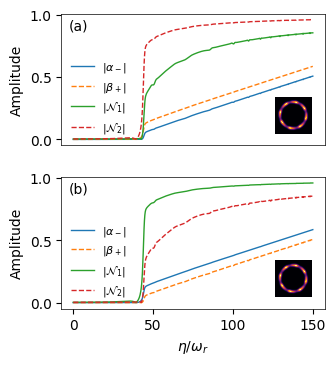

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# LOAD DATA
# ============================================================
data = np.load(r"Figure14_data.npz")

print("\nData loaded successfully.")

eta_vals = data["eta_vals"]
omega_r  = data["omega_r"]

x = eta_vals / omega_r

# steady-state
resA = {
    "a": data["resA_a"],
    "b": data["resA_b"],
    "N1": data["resA_N1"],
    "N2": data["resA_N2"],
}

resB = {
    "a": data["resB_a"],
    "b": data["resB_b"],
    "N1": data["resB_N1"],
    "N2": data["resB_N2"],
}

# density (precomputed!)
dens2D = data["dens2D"]
X = data["X"]
Y = data["Y"]

# ============================================================
# STYLE
# ============================================================
font_labels = 10
font_ticks  = 10
font_legend = 8

plt.rcParams.update({
    "font.size": font_ticks,
    "axes.labelsize": font_labels,
    "xtick.labelsize": font_ticks,
    "ytick.labelsize": font_ticks,
    "legend.fontsize": font_legend,
    "axes.linewidth": 0.5,
})

# ============================================================
# FIGURE
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(3.4, 4.2))
plt.subplots_adjust(hspace=0.02)

# ============================================================
# (a)
# ============================================================
ax = axes[0]

ax.plot(x, resA["a"],  lw=1, label=r"$|\alpha_-|$")
ax.plot(x, resA["b"],  lw=1, ls="--", label=r"$|\beta_+|$")
ax.plot(x, resA["N1"], lw=1, label=r"$|\mathcal{N}_1|$")
ax.plot(x, resA["N2"], lw=1, ls="--", label=r"$|\mathcal{N}_2|$")

ax.set_ylabel("Amplitude")
ax.legend(loc="lower left", frameon=False)
ax.set_box_aspect(0.5)
ax.set_xticks([])
ax.text(0.03, 0.88, '(a)', transform=ax.transAxes)

# inset
axins = inset_axes(
    ax, width="40%", height="70%",
    bbox_to_anchor=(0.6, -0.03, 0.35, 0.40),
    bbox_transform=ax.transAxes,
    borderpad=0
)

axins.pcolormesh(
    X*1e6, Y*1e6, dens2D,
    cmap="inferno", shading="auto",
    vmin=0, vmax=1
)

axins.set_facecolor("black")
axins.set_xticks([])
axins.set_yticks([])
for s in axins.spines.values():
    s.set_visible(False)

# ============================================================
# (b)
# ============================================================
ax = axes[1]

ax.plot(x, resB["a"],  lw=1, label=r"$|\alpha_-|$")
ax.plot(x, resB["b"],  lw=1, ls="--", label=r"$|\beta_+|$")
ax.plot(x, resB["N1"], lw=1, label=r"$|\mathcal{N}_1|$")
ax.plot(x, resB["N2"], lw=1, ls="--", label=r"$|\mathcal{N}_2|$")

ax.set_xlabel(r"$\eta/\omega_r$")
ax.set_ylabel("Amplitude")
ax.legend(loc="lower left", frameon=False)
ax.set_box_aspect(0.5)
ax.text(0.03, 0.88, '(b)', transform=ax.transAxes)

# inset
axins = inset_axes(
    ax, width="40%", height="70%",
    bbox_to_anchor=(0.6, -0.03, 0.35, 0.40),
    bbox_transform=ax.transAxes,
    borderpad=0
)

axins.pcolormesh(
    X*1e6, Y*1e6, dens2D,
    cmap="inferno", shading="auto",
    vmin=0, vmax=1
)

axins.set_facecolor("black")
axins.set_xticks([])
axins.set_yticks([])
for s in axins.spines.values():
    s.set_visible(False)

# ============================================================
plt.show()